# 19 - Complete IBQN Demonstration

## Objetivo
Este é o notebook principal de demonstração da arquitetura Intent-Based
Quantum Networking (IBQN) construída sobre o SeQUeNCe - reúne, num único
fluxo, tudo o que os notebooks 10-18 demonstraram em partes: do intent
declarativo à reconciliação entre episódios, com resultados reais e
reprodutíveis.

## 19.1 - Problema
Uma aplicação quer entrelaçamento fim a fim entre dois nós de uma rede
quântica, com uma fidelidade e um número de pares mínimos, dentro de uma
janela de tempo - **sem conhecer** caminho, protocolo de swap, ou se
purificação será necessária. Isso é o intent: o WHAT, nunca o HOW.


## 19.2 - Topologia

Uma topologia em diamante: duas rotas possíveis entre `r1` e `r3`, com características físicas bem diferentes.


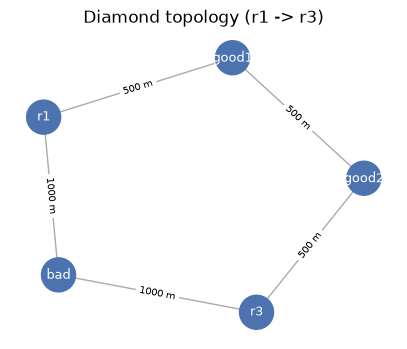

5 nodes: ['r1', 'r3', 'bad', 'good1', 'good2']
5 quantum links


In [1]:
from ibqn.demos.topologies import diamond_spec
from ibqn.demos.visualization import draw_topology
import matplotlib.pyplot as plt

spec = diamond_spec()
fig, ax = plt.subplots(figsize=(5, 4))
draw_topology(spec, title="Diamond topology (r1 -> r3)", ax=ax)
plt.show()

print(f"{len(spec.nodes)} nodes: {[n.id for n in spec.nodes]}")
print(f"{len(spec.quantum_links)} quantum links")


## 19.3 - Intent

O pedido declarativo, como um YAML real (gerado a partir do objeto tipado, para garantir que representa exatamente o que é usado abaixo).


In [2]:
import yaml
from ibqn.demos.intents import diamond_intent

intent = diamond_intent(intent_id="intent-ibqn-demo", requested_pairs=10, min_fidelity=0.6)
print(yaml.dump({"intent": intent.model_dump()}, sort_keys=False))


2026-10-02 15:04:17,365 INFO     ibqn.ibqn.intent.models intent_id=- - IntentRequirements: migrating legacy field 'requested_pairs' -> 'reserved_memory_slots' (see docs/intent_resource_semantics.md)


2026-10-02 15:04:17,367 INFO     ibqn.ibqn.intent.models intent_id=- - IntentRequirements: migrating legacy field 'start_time' -> 'start_time_s' (see docs/intent_resource_semantics.md)


2026-10-02 15:04:17,368 INFO     ibqn.ibqn.intent.models intent_id=- - IntentRequirements: migrating legacy field 'duration' -> 'duration_s' (see docs/intent_resource_semantics.md)


intent:
  id: intent-ibqn-demo
  service: entanglement_distribution
  endpoints:
    source: r1
    destination: r3
  requirements:
    min_fidelity: 0.6
    min_throughput: 1.0
    max_latency: 1.0
    min_delivered_pairs: null
    reserved_memory_slots: 10
    start_time_s: 0.02
    duration_s: 0.1
  policy:
    priority: normal
    allow_rerouting: true
    allow_purification: true
    allow_multiple_paths: false
  validation:
    metrics:
    - delivered_pairs
    success_conditions:
    - metric: delivered_pairs
      operator: '>='
      expected: 10.0



## 19.4 - Planejamento

Caminhos candidatos, estratégia escolhida, plano resultante, estimativas, viabilidade.


In [3]:
from ibqn.network.capabilities import NetworkCapabilities
from ibqn.planning.planner import IntentPlanner
from ibqn.planning.routing import ShortestHopCountRouting
from ibqn.demos.planning import compare_routing_strategies
from ibqn.demos.tables import plan_summary_table, reservations_table

capabilities = NetworkCapabilities(spec)
routing_strategy = ShortestHopCountRouting()  # fewest hops - what a hop-count static provisioning would pick
planner = IntentPlanner(capabilities, routing_strategy=routing_strategy)
plan = planner.plan(intent)

print("Candidate routes considered by this strategy:")
display(compare_routing_strategies(capabilities, intent, {"ShortestHopCount": routing_strategy}))
print(f"\nSelected plan: route={' -> '.join(plan.route)}, feasible={plan.feasible}")
plan_summary_table(plan)


2026-10-02 15:04:17,412 INFO     ibqn.ibqn.planning.planner intent_id=intent-ibqn-demo - planned route r1->bad->r3, estimated_fidelity=0.7300, purification=False


Candidate routes considered by this strategy:


,strategy,rank,route,hops,estimated_loss_db,estimated_fidelity,purification_required,feasible
0,ShortestHopCount,0,r1 -> bad -> r3,2,40.000,0.730,False,True
1,ShortestHopCount,1,r1 -> good1 -> good2 -> r3,3,0.015,0.666,False,True



Selected plan: route=r1 -> bad -> r3, feasible=True


,field,value
0,feasible,True
1,route,r1 -> bad -> r3
2,route_rationale,selected by ShortestHopCountRouting; hop fidel...
3,requires_purification,False
4,purification_rounds_estimate,0
5,swapping_strategy_note,swap order follows SeQUeNCe's default binary-b...
6,estimated_fidelity,0.73
7,estimated_latency_s,0.00002


In [4]:
reservations_table(plan)


,node_id,memories_required,memories_available,satisfied
0,r1,10,20,True
1,bad,20,20,True
2,r3,10,20,True


## 19.5 - Deployment

Rota aplicada, reserva real negociada pelo SeQUeNCe, janela de tempo, recursos.


In [5]:
from sequence.constants import SECOND
from ibqn.network.sequence_adapter import SequenceAdapter
from ibqn.execution.sequence_executor import SequenceExecutor
from ibqn.intent.repository import IntentRepository

SEED_EPISODE_1 = 0

adapter = SequenceAdapter(spec, seed=SEED_EPISODE_1)
repository = IntentRepository()
executor = SequenceExecutor(adapter, repository)
executor.deploy(intent, plan)
executor.run()

source_router = adapter.get_router(intent.endpoints.source)
reservation = source_router.network_manager.protocol_stack[-1].accepted_reservations[0]
print(f"applied route: {' -> '.join(plan.route)}")
print(f"real reservation path: {reservation.path} (matches plan: {reservation.path == plan.route})")
print(f"reservation window: [{reservation.start_time / SECOND:.3f}, {reservation.end_time / SECOND:.3f}) s")
print(f"memory_size requested per pair: {reservation.memory_size}")


2026-10-02 15:04:17,492 INFO     ibqn.ibqn.network.sequence_adapter intent_id=- - topology built: 5 routers, 5 quantum links, formalism=bell_diagonal, seed=0


2026-10-02 15:04:17,494 INFO     ibqn.ibqn.intent.repository intent_id=intent-ibqn-demo - intent registered


2026-10-02 15:04:17,496 INFO     ibqn.ibqn.intent.repository intent_id=intent-ibqn-demo - intent transitioned to VALIDATED (schema validated)


2026-10-02 15:04:17,498 INFO     ibqn.ibqn.intent.repository intent_id=intent-ibqn-demo - intent transitioned to PLANNING (invoking IntentPlanner)


2026-10-02 15:04:17,499 INFO     ibqn.ibqn.intent.repository intent_id=intent-ibqn-demo - intent transitioned to PLANNED (selected by ShortestHopCountRouting; hop fidelities [0.85, 0.85])


2026-10-02 15:04:17,500 INFO     ibqn.ibqn.intent.repository intent_id=intent-ibqn-demo - intent transitioned to DEPLOYING (applying route r1->bad->r3 and submitting reservation to NetworkManager (purification_mode=until_target))


2026-10-02 15:04:17,501 INFO     ibqn.ibqn.execution.sequence_executor intent_id=intent-ibqn-demo - submitting reservation r1 -> r3, reserved_memory_slots=10, min_fidelity=0.600, purification_mode=until_target


2026-10-02 15:04:17,503 INFO     ibqn.ibqn.network.sequence_adapter intent_id=- - running simulation, stop_time=0.200s


2026-10-02 15:04:17,506 INFO     ibqn.ibqn.intent.repository intent_id=intent-ibqn-demo - intent transitioned to ACTIVE (reservation approved)


applied route: r1 -> bad -> r3
real reservation path: ['r1', 'bad', 'r3'] (matches plan: True)
reservation window: [0.020, 0.120) s
memory_size requested per pair: 10


## 19.6 - Operação

Geração, swapping (no nó interior da rota) e entregas reais - observadas via evidência `DELIVERY`, nunca calculadas à parte.


In [6]:
from ibqn.assurance.telemetry import collect_intent_evidence
from ibqn.demos.tables import delivered_pairs_table

evidence_episode_1 = collect_intent_evidence(intent)
pairs_df = delivered_pairs_table(evidence_episode_1)
print(f"delivered pairs (episode 1): {len(evidence_episode_1.delivered_pairs)}")
print(f"interior (swap) node(s) on this route: {plan.route[1:-1]}")
pairs_df.head(5)


delivered pairs (episode 1): 7
interior (swap) node(s) on this route: ['bad']


,pair,local_memory,remote_memory,delivery_time_s,fidelity
0,1,r1.MemoryArray[5],r3.MemoryArray[2],0.030875,0.809467
1,2,r1.MemoryArray[2],r3.MemoryArray[6],0.060486,0.788641
2,3,r1.MemoryArray[4],r3.MemoryArray[8],0.063307,0.773750
3,4,r1.MemoryArray[8],r3.MemoryArray[4],0.072824,0.774995
4,5,r1.MemoryArray[8],r3.MemoryArray[7],0.113363,0.810445


## 19.7 - Assurance

Avaliação das condições declaradas, contra a evidência real coletada acima.


In [7]:
from ibqn.assurance.evaluator import evaluate_intent
from ibqn.assurance.violations import classify_violations
from ibqn.demos.tables import evaluation_table
from ibqn.intent.models import IntentStatus

evaluation_episode_1 = evaluate_intent(intent, evidence_episode_1)
status_episode_1 = IntentStatus.SATISFIED if evaluation_episode_1.satisfied else IntentStatus.VIOLATED
reason = "all success conditions met" if evaluation_episode_1.satisfied else "; ".join(evaluation_episode_1.violations)
repository.transition(intent.id, status_episode_1, reason, sim_time=adapter.get_timeline().now() / SECOND)

print(f"Episode 1 final status: {status_episode_1.value}")
evaluation_table(evaluation_episode_1)


2026-10-02 15:04:22,850 INFO     ibqn.ibqn.intent.repository intent_id=intent-ibqn-demo - intent transitioned to VIOLATED (delivered_pairs >= 10.0 (observed=7.0) -> FAIL)


Episode 1 final status: VIOLATED


,metric,operator,expected,observed,passed,evidence_source
0,delivered_pairs,>=,10.0,7.0,False,7 DELIVERY event(s) tagged intent_id='intent-i...


In [8]:
violations = classify_violations(evaluation_episode_1)
for v in violations:
    print(f"violation: category={v.category.value}, metric={v.metric}, expected={v.expected}, observed={v.observed}")


violation: category=delivered_pairs, metric=delivered_pairs, expected=10.0, observed=7.0


## 19.8 - Reconciliation

Se o episódio 1 violou, um segundo episódio - nova `Timeline`, nova estratégia de roteamento - tenta satisfazer o mesmo intent.


In [9]:
from ibqn.assurance.reconciliation import reconcile
from ibqn.planning.routing import LeastLossRouting

if status_episode_1 == IntentStatus.VIOLATED:
    reconciliation_result = reconcile(
        intent, spec, repository, evaluation_episode_1,
        seed=1, routing_strategy=LeastLossRouting(),
    )
    status_episode_2 = reconciliation_result.final_status
    route_episode_2 = reconciliation_result.new_plan.route
    evaluation_episode_2 = reconciliation_result.new_evaluation
    print(f"Episode 2 route: {' -> '.join(route_episode_2)}")
    print(f"Episode 2 final status: {status_episode_2.value}")
else:
    status_episode_2 = None
    print("Episode 1 was already SATISFIED - no reconciliation needed for this run.")


2026-10-02 15:04:22,905 INFO     ibqn.ibqn.intent.repository intent_id=intent-ibqn-demo - intent transitioned to RECONCILING (violation detected: delivered_pairs)


2026-10-02 15:04:22,907 INFO     ibqn.ibqn.intent.repository intent_id=intent-ibqn-demo - intent transitioned to PLANNING (recompiling with a new plan for a new episode)


2026-10-02 15:04:22,910 INFO     ibqn.ibqn.planning.planner intent_id=intent-ibqn-demo - planned route r1->good1->good2->r3, estimated_fidelity=0.6660, purification=False


2026-10-02 15:04:22,918 INFO     ibqn.ibqn.network.sequence_adapter intent_id=- - topology built: 5 routers, 5 quantum links, formalism=bell_diagonal, seed=1


2026-10-02 15:04:22,920 INFO     ibqn.ibqn.intent.repository intent_id=intent-ibqn-demo - intent transitioned to PLANNED (selected by LeastLossRouting; hop fidelities [0.85, 0.9, 0.85])


...

2026-10-02 15:04:22,927 INFO     ibqn.ibqn.network.sequence_adapter intent_id=- - running simulation, stop_time=0.200s


2026-10-02 15:04:22,932 INFO     ibqn.ibqn.intent.repository intent_id=intent-ibqn-demo - intent transitioned to ACTIVE (reservation approved)


2026-10-02 15:04:31,981 INFO     ibqn.ibqn.intent.repository intent_id=intent-ibqn-demo - intent transitioned to SATISFIED (all success conditions met after reconciliation)


2026-10-02 15:04:31,983 INFO     ibqn.ibqn.assurance.reconciliation intent_id=intent-ibqn-demo - reconciliation outcome: SATISFIED (route=r1->good1->good2->r3)


Episode 2 route: r1 -> good1 -> good2 -> r3
Episode 2 final status: SATISFIED


## 19.9 - Resultado final


In [10]:
print(f"Initial status:            {status_episode_1.value}")
if status_episode_2 is not None:
    print(f"Reconciliation action:     replanned with LeastLossRouting on a new Timeline (seed=1)")
    print(f"Final status:              {status_episode_2.value}")
else:
    print("Final status:              (no reconciliation triggered)")

final_status = repository.get(intent.id).lifecycle.status
history = [t.to_status.value for t in repository.get(intent.id).lifecycle.history]
print()
print("Full lifecycle history:")
print(" -> ".join(history))


Initial status:            VIOLATED
Reconciliation action:     replanned with LeastLossRouting on a new Timeline (seed=1)
Final status:              SATISFIED

Full lifecycle history:
RECEIVED -> VALIDATED -> PLANNING -> PLANNED -> DEPLOYING -> ACTIVE -> VIOLATED -> RECONCILING -> PLANNING -> PLANNED -> DEPLOYING -> ACTIVE -> SATISFIED


In [11]:
assert status_episode_1 == IntentStatus.VIOLATED, "this demonstration is only complete when episode 1 genuinely violates"
assert status_episode_2 == IntentStatus.SATISFIED, "reconciliation must genuinely recover the intent"
assert final_status == IntentStatus.SATISFIED
assert "RECONCILING" in history
print("\nComplete cycle confirmed: VIOLATED -> RECONCILING -> ... -> SATISFIED, all from real simulation results.")



Complete cycle confirmed: VIOLATED -> RECONCILING -> ... -> SATISFIED, all from real simulation results.


## 19.10 - Arquitetura

```text
Application
    |
    v
Intent (WHAT: EntanglementIntent)
    |
    v
Validation (Pydantic schema + lifecycle RECEIVED -> VALIDATED)
    |
    v
Planner (IntentPlanner: RoutingStrategy + PurificationStrategy + SwappingStrategy)
    |
    v
ExecutionPlan (HOW: route, estimated fidelity, purification decision)
    |
    v
SeQUeNCe Adapter (NetworkTopologySpec -> RouterNetTopo + Timeline)
    |
    v
Quantum Network Simulation (real generation/swapping/purification)
    |
    v
DELIVERY Events (tagged with intent_id, via IntentRequestApp)
    |
    v
Intent Assurance (IntentEvidence -> IntentEvaluation -> Violation)
    |
    v
SATISFIED / VIOLATED
    |
    v
Reconciliation (new episode: new Timeline, same IntentRepository)
```

Cada seta acima corresponde a um módulo real de `src/ibqn/` - nenhuma
etapa deste diagrama é conceitual sem uma implementação correspondente
testada (ver `docs/architecture.md`).

## Interpretação
Este notebook percorreu a arquitetura inteira com um único intent real:
da declaração (WHAT) ao plano (HOW), da simulação real à evidência
`DELIVERY`, do veredito de assurance a uma reconciliação genuína entre
dois episódios independentes. Cada número mostrado (rota, janela, pares
entregues, fidelidade, status) vem de uma chamada real a
`src/ibqn`/SeQUeNCe - nenhum foi calculado ou fixado fora da simulação.

## Limitações
Consolidação das limitações já documentadas nos notebooks anteriores:
- Roteamento: só topologias pequenas são tratáveis por
  `HighestFidelityRouting` (notebook 12).
- Assurance: só decide após a simulação rodar - o planner v1 não estima
  throughput (notebooks 13/14).
- Reconciliation: entre episódios (nova `Timeline`), não reconfiguração
  ao vivo; tenta uma vez, não converge iterativamente (notebook 15).
- Purificação: a estimativa padrão é de um round analítico; a política
  executada (`never`/`once`/`until_target`) é a do plano, e nenhuma
  estimativa modela o custo em pares nem a decoerência durante a espera
  (notebook 17).
- Múltiplos intents: não podem compartilhar um roteador como
  origem/destino nesta versão (notebook 18).

## Conclusão
A arquitetura IBQN completa - do intent declarativo à reconciliação entre
episódios - demonstrada de ponta a ponta com resultados reais e
reprodutíveis, servindo de material de apresentação e suplementar para o
projeto.
